# Visualization for deliveries per month
Thought showing visualizations for the number of deliveries per month might be interesting.
Could also do something to show the person receiving the most deliveries for each month?

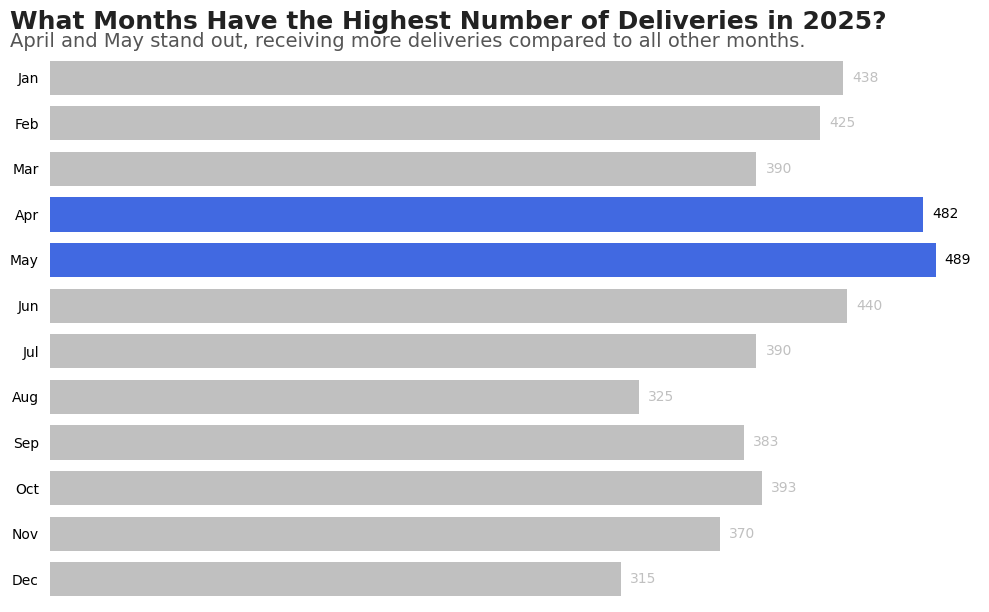

In [22]:
import pandas as pd
from MonthEnum import Date
import matplotlib.pyplot as plt


df = pd.read_csv("../Data/PantrytoPorchData2025.csv")
df = df[["Date"]]

temp_dict = {}

for row in df.itertuples():
    date_num = int(row.Date.split("/")[0])
    cur_date = Date(date_num).name
    
    if cur_date not in temp_dict:
        temp_dict[cur_date] = 1
    
    else:
        temp_dict[cur_date] += 1

month_deliveries = pd.DataFrame.from_dict(temp_dict, orient='index', columns=['Total Deliveries'])
month_deliveries.index.name = 'Month'
month_deliveries = month_deliveries.reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
target_months = ["Apr", "May"]
for row in month_deliveries.itertuples():
    cur_month = row[1]
    num_deliveries = row[2]
    if cur_month in target_months:
        ax.barh(cur_month, num_deliveries, color = "royalblue", height = 0.75)
        ax.text(num_deliveries + 5, row.Index, num_deliveries, va="center")
    else:
        ax.barh(cur_month, num_deliveries, color = "silver", height = 0.75)
        ax.text(num_deliveries + 5, row.Index, num_deliveries, va="center", color = "silver")

ax.invert_yaxis()
ax.spines[["left", "top", "right", "bottom"]].set_visible(False)
ax.tick_params("both", length = 0, labelsize = 10, pad = 8)
ax.set_xticklabels([])
ax.set_ylim(11.5, -1) # I don't know why its -1. I was trying to remove the extra white space at the bottom.


main = "What Months Have the Highest Number of Deliveries in 2025?"
sub = "April and May stand out, receiving more deliveries compared to all other months."
fig.text(0.015, 0.98, main, ha="left", fontsize=18, color="#222222", weight="bold") # Main
fig.text(0.015, 0.95, sub, ha="left", fontsize=14, color="#555555") # Sub

plt.tight_layout()
plt.show()

# Comparing delivery trends between 2024 and 2025
Found a trend towards the majority of deliveries happening in the first half of the year in 2025, adding 2024 to see if it's common

In [ ]:
# Get data for 2024
df_24 = pd.read_csv("../Data/allyears.csv", index_col="id")
df_24['date'] = pd.to_datetime(df_24['date'])

df_24['month'] = df_24['date'].dt.month
df_24['month'] = df_24['date'].dt.month_name()
df_24['year'] = df_24['date'].dt.year
df_24 = df_24[["month", "year"]]

df_24.head()
temp_dict = {}
for row in df_24.itertuples():
    year = row[2]
    # print(year)
    month = row[1][0:3]
    # print(month)
    if year == 2024:
        if month not in temp_dict:
            temp_dict[month] = 1
            # print(month)
        
        else:
            temp_dict[month] += 1

# print(temp_dict)
month_deliveries_24 = pd.DataFrame.from_dict(temp_dict, orient='index', columns=['Total Deliveries'])
month_deliveries_24.index.name = 'Month'
month_deliveries_24 = month_deliveries_24.reset_index()
# print(month_deliveries_24)

   Month  Total Deliveries
0    Jan               260
1    Feb               257
2    Mar               303
3    Apr               293
4    May               366
5    Jun               252
6    Jul               301
7    Aug               338
8    Sep               338
9    Oct               346
10   Nov               352
11   Dec               322


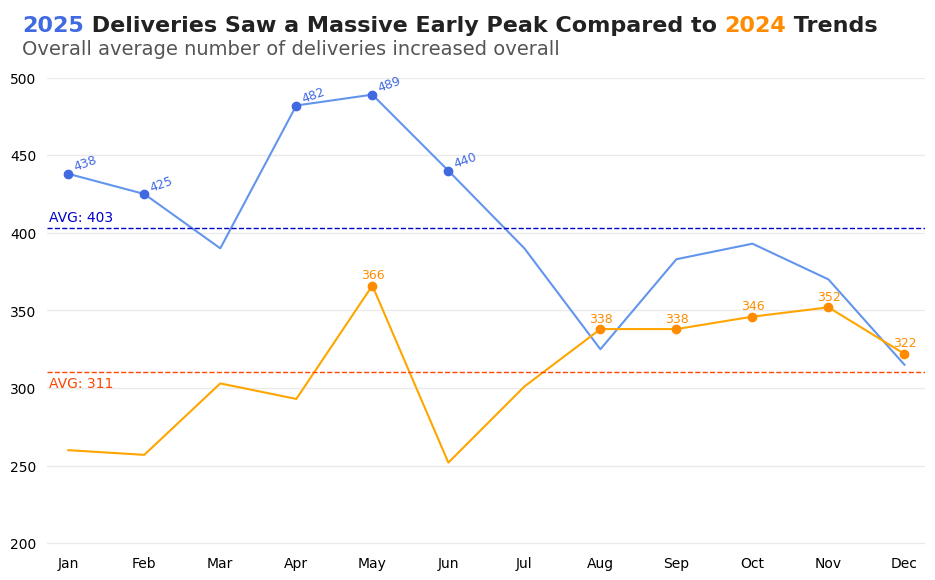

In [147]:
from highlight_text import fig_text

fig, ax = plt.subplots(figsize=(10, 6))

# Using same df as above
avg_delv = month_deliveries["Total Deliveries"].sum() / 12
avg_delv_24 = month_deliveries_24["Total Deliveries"].sum() / 12

# 2025
# ax.set_title(f"2025\nAverage monthly deliveries: {avg_delv:.0f}", loc="left", fontsize=12)

ax.plot("Month", "Total Deliveries", data=month_deliveries, color = "cornflowerblue", label = "2025")
for row in month_deliveries.itertuples():
    cur_month = row[1]
    cur_delv = row[2]
    month_num = Date[cur_month].value

    if cur_delv >= avg_delv:
        # ax.text(month_num - 0.95, cur_delv + 1.75, cur_month, rotation = 30)
        ax.text(
            month_num - 0.95, cur_delv + 2, cur_delv,
            rotation=20, ha="left", fontsize=9, color="royalblue"
            )
        ax.plot(cur_month, cur_delv, marker="o", color="royalblue", markersize=6)

ax.axhline(avg_delv, linestyle="--", color = "mediumblue", linewidth = 1)
ax.text(-0.25, avg_delv+4, f"AVG: {avg_delv:.0f}", color = "mediumblue")



# 2024
# axs[1].set_title(f"2024\nAverage monthly deliveries: {avg_delv_24:.0f}", loc="left", fontsize=12)
ax.plot("Month", "Total Deliveries", data=month_deliveries_24, color = "orange", label = "2024")
for row in month_deliveries_24.itertuples():
    cur_month = row[1]
    cur_delv = row[2]
    month_num = Date[cur_month].value

    if cur_delv >= avg_delv_24:
        # ax.text(month_num - 0.95, cur_delv + 1.75, cur_month, rotation = 30)
        ax.text(
            month_num - 1.15, cur_delv + 4.5, cur_delv,
            ha="left", fontsize=9, color="darkorange",
            )
        ax.plot(cur_month, cur_delv, marker="o", color="darkorange", markersize=6)

ax.axhline(avg_delv_24, linestyle="--", color = "orangered", linewidth = 1)
ax.text(-0.25, avg_delv_24-10, f"AVG: {avg_delv_24:.0f}", color = "orangered")



ax.set_ylim(199, 500)
ax.set_yticks([200, 250, 300, 350, 400, 450, 500])
# axs[1].set_ylim(199, 500)
# axs[1].set_yticks([200, 250, 300, 350, 400])


# for i in range(2):
ax.spines[["left", "top", "right", "bottom"]].set_visible(False)
ax.tick_params("both", length = 0, labelsize = 10, pad = 8)
ax.yaxis.grid(color="#BDBCBC", linewidth=1, alpha = 0.3)
ax.margins(y=0, x= 0.025)


main = "<2025> Deliveries Saw a Massive Early Peak Compared to <2024> Trends"
fig_text(
    0.06, 0.95, main, ha="left", fontsize=16, color="#222222", weight="bold",
    highlight_textprops=[
        {"color": "royalblue"},
        {"color": "darkorange"}
        ]
    )

sub = "Overall average number of deliveries increased overall"
fig_text(0.06, 0.91, sub, ha="left", fontsize=14, color="#555555")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()